In [21]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
import numpy as np
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
# import geopandas as gpd
import pandas as pd
import seaborn as sns
from scipy.stats import qmc
from ipywidgets import IntProgress
import math as math

# importeren van ewatercycle
import ewatercycle
import ewatercycle.models
import ewatercycle.forcing

from ewatercycle_discharge import DischargeLocal

shape_file_area = 7.629080e+03 # in km^2
# parameters = np.array([0, 0.1, 1])

In [15]:
basin_name = "Frans"

# tijdsinterval
start_datum = "2019-01-01"
eind_datum = "2024-12-31"
start_datum = pd.to_datetime(start_datum, utc=True)
end_datum = pd.to_datetime(eind_datum, utc=True)
start_pd = start_datum.strftime("%Y-%m-%dT%H:%M")
end_pd = end_datum.strftime("%Y-%m-%dT%H:%M")
start_datum = start_pd
eind_datum = end_pd

print(start_datum)

# route naar shape file
shapefile = Path.home() / "BEP-Julian" / "BEP-Julian" / "Suriname_Model" / "boven_suriname.shp"

Eigen_model = Path.home() / "BEP-Julian" / "BEP-Julian" / "Suriname_Model" / "discharge_bmi"
Eigen_model.mkdir(exist_ok=True)

forcing_route = Path.home() / "BEP-Julian" / "BEP-Julian" / "Forcing" / "ERA5_SUR_2018_2026"/ "work" / "diagnostic" / "script" / "work" / "diagnostic" / "script"
# forcing_route.mkdir(exist_ok=True)

# genereren
# ERA5_forcing = ewatercycle.forcing.sources['LumpedMakkinkForcing'].generate(
#     dataset="ERA5",
#     start_time=start_datum,
#     end_time=eind_datum,
#     shape=shapefile,
#     directory=forcing_route
# )

# inladen
ERA5_forcing = ewatercycle.forcing.sources["LumpedMakkinkForcing"].load(directory=forcing_route)

print(f"The forcing object you created: \n {ERA5_forcing}")

2019-01-01T00:00
The forcing object you created: 
 start_time='2018-12-01T00:00:00Z' end_time='2024-12-31T00:00:00Z' directory=PosixPath('/home/julian/BEP-Julian/BEP-Julian/Forcing/ERA5_SUR_2018_2026/work/diagnostic/script/work/diagnostic/script') shape=PosixPath('/home/julian/BEP-Julian/BEP-Julian/Forcing/ERA5_SUR_2018_2026/work/diagnostic/script/work/diagnostic/script/boven_suriname.shp') filenames={'pr': 'OBS6_ERA5_reanaly_1_day_pr_2018-2024.nc', 'tas': 'OBS6_ERA5_reanaly_1_day_tas_2018-2024.nc', 'rsds': 'OBS6_ERA5_reanaly_1_day_rsds_2018-2024.nc', 'evspsblpot': 'Derived_Makkink_evspsblpot.nc'}


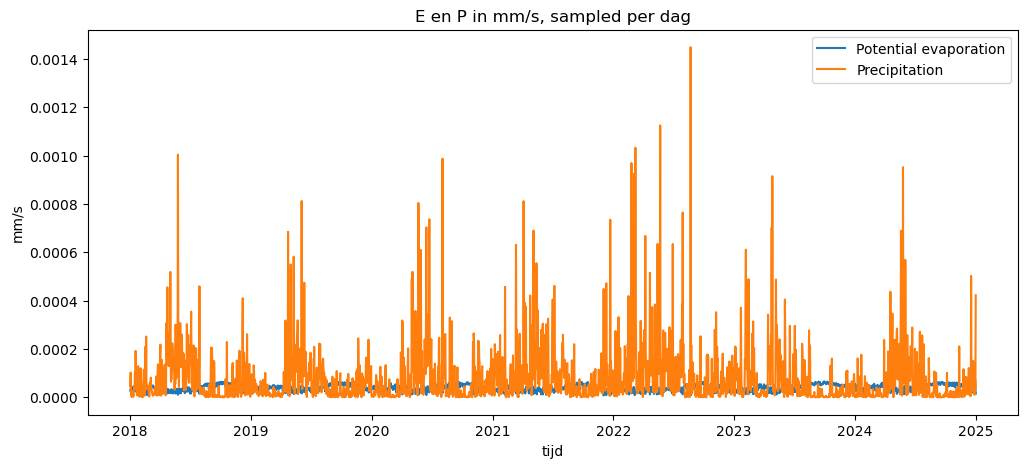

In [16]:
evap = ERA5_forcing.to_xarray()["evspsblpot"] #units: kg m^-2 s^-1 = mm/s, gesampled per dag
prec = ERA5_forcing.to_xarray()["pr"] #units: kg m^-2 s^-1 = mm/s, gesampled per dag
# print(evap)
# print(prec)
fig, ax = plt.subplots(figsize=(12,5))

evap.plot(ax=ax, label='Potential evaporation')
prec.plot(ax=ax, label='Precipitation')
ax.set_ylabel('mm/s')
ax.set_xlabel("tijd")
plt.title("E en P in mm/s, sampled per dag")
ax.legend();

In [18]:
opp_file = Path.home() / "BEP-Julian" / "BEP-Julian" / "Suriname_Model" / "GWSC_dams_mogwai_Brokopondo.csv"
opp = pd.read_csv(opp_file, delimiter=',', skiprows = 1)
opp = opp.rename(columns={"Time (UTC)": "Date"})
opp["Date"] = pd.to_datetime(opp["Date"], utc = True)
opp["Date"] = opp["Date"].dt.tz_localize(None)
opp = opp[(opp["Date"] >= start_datum) &(opp["Date"] <= eind_datum)].copy()

In [19]:
height_file = Path.home() / "BEP-Julian" / "BEP-Julian" / "Suriname_Model" / "Dahiti Brokopondo water height.xlsx"
height = pd.read_excel(height_file)
height = height.iloc[:, 0].str.split(';', expand=True)
height.columns = ["datetime", "wse", "wse_u"]
height["datetime"] = pd.to_datetime(height["datetime"], utc=True)
height["wse"] = height["wse"].astype(float)
height["wse_u"] = height["wse_u"].astype(float)

In [22]:
H = height["wse"]
V = np.zeros(len(H))
# H = 8 + 15*np.log(V+2) met np.log = ln
# V = math.exp((H-8)/15)-2
for i in range(len(H)):
    V[i] = math.exp((H[i]-8)/15)-2

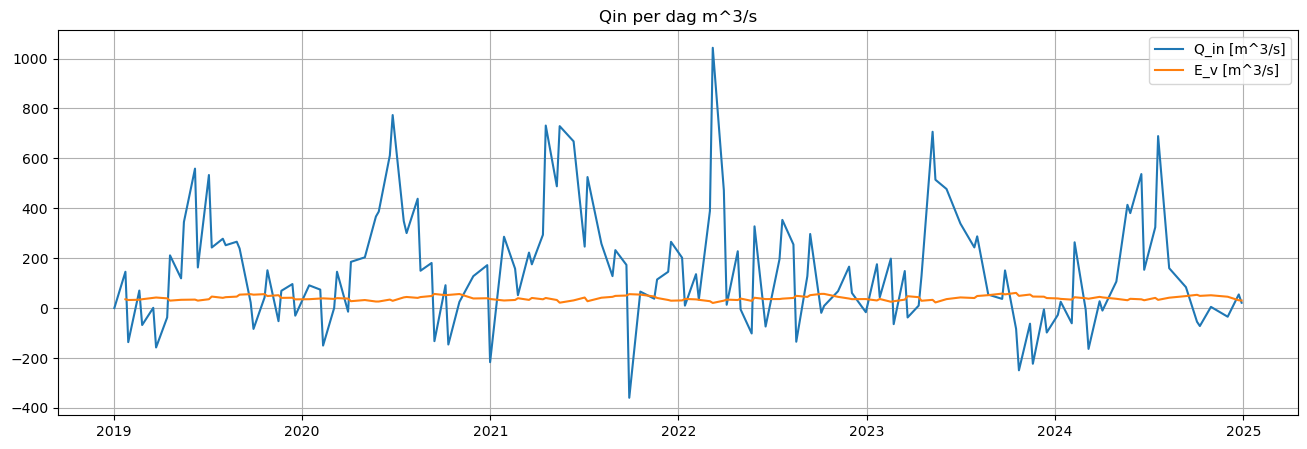

In [23]:
#Laadt in Qin links van Suriname model
height["datetime_local_none_test"] = height["datetime"].dt.tz_localize(None)
fig, ax1 = plt.subplots(figsize=(16,5))

begin_datum = pd.to_datetime(start_datum)
eind_datum = pd.to_datetime(eind_datum)
evap = evap.sel(time=slice(begin_datum, eind_datum))

height["datetime_local_none_test"] = height["datetime_local_none_test"][
    (height["datetime_local_none_test"] >= begin_datum) &
    (height["datetime_local_none_test"] <= eind_datum)
].copy()
height = height.reset_index(drop=True)

area_interp = np.interp(height["datetime_local_none_test"].astype("int64"), opp["Date"].astype("int64"), opp["Value"])
Vv = V * 10**9                                                            # van km^3 naar m^3
delta_s = np.zeros(len(height["datetime_local_none_test"]))
E = np.zeros(len(height["datetime_local_none_test"]))
opper = np.zeros(len(height["datetime_local_none_test"]))
Q_in_L = np.zeros(len(height["datetime_local_none_test"]))
E_v = np.zeros(len(height["datetime_local_none_test"]))
Q_in_L_sum = np.zeros(len(height["datetime_local_none_test"]))
Q_in_L_sum_test = np.zeros(len(height["datetime_local_none_test"]))
Q_out = 144.7# m^3/s 

for i in range(len(height["datetime_local_none_test"])-1):
    
    t0 = height["datetime_local_none_test"].iloc[i]
    t1 = height["datetime_local_none_test"].iloc[i+1]

    # delta_s[i+1] = (Vv[i+1] - Vv[i])* (1/(3600* 24))
    dt_seconds = (t1 - t0).total_seconds()
    delta_s[i+1] = (Vv[i+1] - Vv[i]) / dt_seconds
    
    evap_interval = evap.sel(time=slice(t0, t1))
    E[i+1] = evap_interval.mean().values * 10**-3 #/dt_seconds       # van mm/s naar m/s

    A_t = area_interp[i+1]
    E_v[i+1] = A_t * 1e6 * E[i+1]

    Q_in_L[i+1] = delta_s[i+1] + E_v[i+1] + Q_out
    Q_in_L[i+1] = np.nan_to_num(Q_in_L[i+1], nan=0.0)
    Q_in_L_sum[i] = Q_in_L.sum()
    Q_in_L_sum_test = np.cumsum(Q_in_L)

plt.plot(height["datetime_local_none_test"], Q_in_L, label = "Q_in [m^3/s]")
plt.plot(height["datetime_local_none_test"], E_v, label = "E_v [m^3/s]")
plt.legend()
plt.title("Qin per dag m^3/s")
plt.grid();

In [ ]:
flow = pd.DataFrame(data=df["Value"].values, index=df["Date"], columns=['Q'])
flow.index = pd.to_datetime(flow.index).tz_localize(None)

## RMSE functie

In [ ]:
def RMSE(output, observed, start, end):
    start = pd.to_datetime(start)
    end = pd.to_datetime(end)
    
    output.index = pd.to_datetime(output.index)
    observed.index = pd.to_datetime(observed.index)

    hydro_data = pd.concat([output.reindex(observed.index, method='ffill'), observed], axis=1, keys=['model', 'observation'])
    hydro_data = hydro_data.dropna()
    
    hydro_data = hydro_data[(hydro_data.index > start) & (hydro_data.index < end)]
    
    squarediff = (hydro_data['model'] - hydro_data['observation']) ** 2
    rootMeanSquareDiff = np.sqrt(np.mean(squarediff))
    
    return rootMeanSquareDiff

## NSE functie

In [ ]:
def NSE(output, observed, start, end):
    start = pd.to_datetime(start)
    end = pd.to_datetime(end)
    
    output.index = pd.to_datetime(output.index)
    observed.index = pd.to_datetime(observed.index)

    hydro_data = pd.concat([output.reindex(observed.index, method='ffill'), observed], axis=1, keys=['model', 'observation'])
    hydro_data = hydro_data.dropna()
    
    hydro_data = hydro_data[(hydro_data.index > start) & (hydro_data.index < end)]

    #hier de formule van NSE invoegen
    
    top = np.sum((hydro_data['observation'] - hydro_data['model'])**2)

    bottom = np.sum((hydro_data['observation']- hydro_data['observation'].mean())**2)

    nse = 1 - (top / bottom)
    
    return nse

## log NSE functie

In [ ]:
def logNSE(output, observed, start, end):
    start = pd.to_datetime(start)
    end = pd.to_datetime(end)
    
    output.index = pd.to_datetime(output.index)
    observed.index = pd.to_datetime(observed.index)

    hydro_data = pd.concat([output.reindex(observed.index, method='ffill'), observed], axis=1, keys=['model', 'observation'])
    hydro_data = hydro_data.dropna()
    
    hydro_data = hydro_data[(hydro_data.index > start) & (hydro_data.index < end)]

    #hier de formule van NSE invoegen
    
    top = np.sum((np.log10(hydro_data['observation']) - np.log10(hydro_data['model']))**2)

    bottom = np.sum((np.log10(hydro_data['observation']) - np.log10(hydro_data['observation']).mean())**2)

    lognse = 1 - (top / bottom)
    
    return lognse

## Parameters genereren

In [ ]:
N = 50 # 50 voor show, 200 voor test, 2000 voor kalibratie

In [ ]:
param_names = ["Qgw", "alpha", "beta"]
param_mins = np.array([0, 0, 1])
param_maxs = np.array([10, 1, 5])

#Fill the parameters array with N random values between each minimum and maximum 
sampler = qmc.LatinHypercube(d=len(param_names))
sample = sampler.random(n=N)
parameters = qmc.scale(sample, param_mins, param_maxs)
print(list(zip(param_names, np.round(parameters[0], decimals=3))))
print(parameters)

In [ ]:
def mmday_to_m3s(Q_sim_mmday, frans_area):
    return (Q_sim_mmday * shape_file_area) / 86.4

In [ ]:
print(type(parameters))
print(parameters.shape)
print(parameters[0])
print(type(parameters[0]))

## RMSE 

In [ ]:
ensemble = []

for counter in range(N): 
    print(counter, parameters[counter])
    ensemble.append(DischargeLocal(forcing=ERA5_forcing))
    config_file, _ = ensemble[counter].setup(parameters = parameters[counter], cfg_dir = Eigen_model)
    ensemble[counter].initialize(config_file)

In [ ]:
f = IntProgress(min=0, max=N)
display(f)

# Array to store level of fit values
objectives_RMSE = []

# Loop over ensemble members
for ensembleMember in ensemble:
    Q_m_RMSE = []
    time_RMSE = []
    while ensembleMember.time < ensembleMember.end_time:
        ensembleMember.update()
        discharge_this_timestep = ensembleMember.get_value("Q")
        Q_m_RMSE.append(discharge_this_timestep[0])
        time_RMSE.append(ensembleMember.time_as_datetime)

    # Create DataFrame for model results
    Q_m_RMSE = mmday_to_m3s(np.array(Q_m_RMSE), shape_file_area)
    discharge_dataframe = pd.DataFrame({'model output': Q_m_RMSE}, index=pd.to_datetime(time_RMSE))
    
    # Calculate the model of best-fit function
    fit_RMSE = RMSE(discharge_dataframe['model output'], flow['Q'], start_calibration, end_calibration)
    objectives_RMSE.append(fit_RMSE)

    # Free up memory
    del Q_m_RMSE, time_RMSE, discharge_dataframe, fit_RMSE
    f.value += 1

# Clean up models to save memory
for ensembleMember in ensemble:
    ensembleMember.finalize()

In [ ]:
parameters_RMSE_index = np.argmin(np.array(objectives_RMSE))
if np.min(np.array(objectives_RMSE)) == np.inf:
    print("No real parameter is chosen")

parameters_RMSE = parameters[parameters_RMSE_index]

print(f'The best RMSE parameters are: {list(zip(param_names, np.round(parameters_RMSE, decimals=3)))}')
print(parameters_RMSE)
print(len(parameters))
print(np.min(np.array(objectives_RMSE)))

In [ ]:
rmse = np.array(objectives_RMSE)

best_10_indices = np.argpartition(rmse, 10)[:10]
best_10_indices = best_10_indices[np.argsort(rmse[best_10_indices])]
best_10_parameters = parameters[best_10_indices]

param_boundary = [[]]
for i in range(9):
    # print(i)
    param_min = np.min(best_10_parameters[:,i])
    param_max = np.max(best_10_parameters[:,i])
    param_boundary.append([param_min, param_max])

print(param_boundary)

# print(best_10_parameters[:,7])
# print(best_10_parameters)

## NSE

In [ ]:
# ensemble = []

# for counter in range(N): 
#     ensemble.append(ewatercycle.models.HBVLocal(forcing=ERA5_forcing))
#     config_file, _ = ensemble[counter].setup(parameters = parameters[counter],  initial_storage=s_0, cfg_dir = HBV_model)
#     ensemble[counter].initialize(config_file)

In [ ]:
# f = IntProgress(min=0, max=N)
# display(f)

# # Array to store level of fit values
# objectives_NSE = []

# # Loop over ensemble members
# for ensembleMember in ensemble:
#     Q_m_NSE = []
#     time_NSE = []
#     while ensembleMember.time < ensembleMember.end_time:
#         ensembleMember.update()
#         discharge_this_timestep = ensembleMember.get_value("Q")
#         Q_m_NSE.append(discharge_this_timestep[0])
#         time_NSE.append(ensembleMember.time_as_datetime)

#     # Create DataFrame for model results
#     Q_m_NSE = mmday_to_m3s(np.array(Q_m_NSE), frans_area)
#     discharge_dataframe = pd.DataFrame({'model output': Q_m_NSE}, index=pd.to_datetime(time_NSE))
    
#     # Calculate the model of best-fit function
#     fit_NSE = NSE(discharge_dataframe['model output'], flow['Q'], start_calibration, end_calibration)
#     objectives_NSE.append(fit_NSE)

#     # Free up memory
#     del Q_m_NSE, time_NSE, discharge_dataframe, fit_NSE
#     f.value += 1

# # Clean up models to save memory
# for ensembleMember in ensemble:
#     ensembleMember.finalize()

In [ ]:
# parameters_NSE_index = np.argmax(np.array(objectives_NSE))
# if np.min(np.array(objectives_NSE)) == np.inf:
#     print("No real parameter is chosen")

# parameters_NSE = parameters[parameters_NSE_index]

# print(f'The best NSE parameters are: {list(zip(param_names, np.round(parameters_NSE, decimals=3)))}')
# print(parameters_NSE)
# print(len(parameters))
# print(np.max(np.array(objectives_NSE)))

In [ ]:
# nse = np.array(objectives_NSE)

# best_10_indices = np.argpartition(nse, 10)[:10]
# best_10_indices = best_10_indices[np.argsort(nse[best_10_indices])]
# best_10_parameters = parameters[best_10_indices]

# param_boundary = [[]]
# for i in range(9):
#     # print(i)
#     param_min = np.min(best_10_parameters[:,i])
#     param_max = np.max(best_10_parameters[:,i])
#     param_boundary.append([param_min, param_max])

# print(param_boundary)

# # print(best_10_parameters[:,7])
# # print(best_10_parameters)

## log NSE

In [ ]:
# ensemble = []

# for counter in range(N): 
#     ensemble.append(ewatercycle.models.HBVLocal(forcing=ERA5_forcing))
#     config_file, _ = ensemble[counter].setup(parameters = parameters[counter],  initial_storage=s_0, cfg_dir = HBV_model)
#     ensemble[counter].initialize(config_file)

In [ ]:
# f = IntProgress(min=0, max=N)
# display(f)

# # Array to store level of fit values
# objectives_logNSE = []

# # Loop over ensemble members
# for ensembleMember in ensemble:
#     Q_m_logNSE = []
#     time_logNSE = []
#     while ensembleMember.time < ensembleMember.end_time:
#         ensembleMember.update()
#         discharge_this_timestep = ensembleMember.get_value("Q")
#         Q_m_logNSE.append(discharge_this_timestep[0])
#         time_logNSE.append(ensembleMember.time_as_datetime)

#     # Create DataFrame for model results
#     Q_m_logNSE = mmday_to_m3s(np.array(Q_m_logNSE), frans_area)
#     discharge_dataframe = pd.DataFrame({'model output': Q_m_logNSE}, index=pd.to_datetime(time_logNSE))
    
#     # Calculate the model of best-fit function
#     fit_logNSE = logNSE(discharge_dataframe['model output'], flow['Q'], start_calibration, end_calibration)
#     objectives_logNSE.append(fit_logNSE)

#     # Free up memory
#     del Q_m_logNSE, time_logNSE, discharge_dataframe, fit_logNSE
#     f.value += 1

# # Clean up models to save memory
# for ensembleMember in ensemble:
#     ensembleMember.finalize()

In [ ]:
# parameters_logNSE_index = np.argmax(np.array(objectives_logNSE))
# if np.min(np.array(objectives_logNSE)) == np.inf:
#     print("No real parameter is chosen")

# parameters_logNSE = parameters[parameters_logNSE_index]

# print(f'The best logNSE parameters are: {list(zip(param_names, np.round(parameters_logNSE, decimals=3)))}')
# print(parameters_logNSE)
# print(len(parameters))
# print(np.max(np.array(objectives_logNSE)))

In [ ]:
# lognse = np.array(objectives_logNSE)

# best_10_indices = np.argpartition(lognse, 10)[:10]
# best_10_indices = best_10_indices[np.argsort(lognse[best_10_indices])]
# best_10_parameters = parameters[best_10_indices]

# param_boundary = [[]]
# for i in range(9):
#     # print(i)
#     param_min = np.min(best_10_parameters[:,i])
#     param_max = np.max(best_10_parameters[:,i])
#     param_boundary.append([param_min, param_max])

# print(param_boundary)

# # print(best_10_parameters[:,7])
# # print(best_10_parameters)

## Visualiseren

run rmse

In [ ]:


# model = ewatercycle.models.HBV(forcing=ERA5_forcing)
# config_file, _ = model.setup(parameters=parameters, initial_storages=s_0, cfg_dir=Eigen_model)

model = DischargeLocal(forcing = ERA5_forcing)
config_file, _ = model.setup(parameters=parameters, cfg_dir=Eigen_model)

model.initialize(config_file)
Q_m = []
time = []

while model.time < model.end_time:
    model.update()
    Q_m.append(model.get_value("Q")[0])
    time.append(pd.Timestamp(model.time_as_datetime))

model.finalize()

In [ ]:
model_output_mmday = pd.Series(data=Q_m, name="Modelled discharge", index=time)
# print(model_output_mmday.max())
model_output_m3s_test = model_output_mmday * shape_file_area * 1000 / 86400

# observed_output = pd.Series(data=df["Value"].to_numpy(), name="Observed discharge", index=df["Date"])
# print(model_output_m3s_test)

run nse

In [ ]:
# from ewatercycle_discharge import DischargeLocal

# # model = ewatercycle.models.HBV(forcing=ERA5_forcing)
# # config_file, _ = model.setup(parameters=parameters, initial_storages=s_0, cfg_dir=Eigen_model)

# model = DischargeLocal(forcing = ERA5_forcing)
# config_file, _ = model.setup(parameters=parameters, cfg_dir=Eigen_model)

# model.initialize(config_file)
# Q_m = []
# time = []

# while model.time < model.end_time:
#     model.update()
#     Q_m.append(model.get_value("Q")[0])
#     time.append(pd.Timestamp(model.time_as_datetime))

# model.finalize()

In [ ]:
# model_output_mmday = pd.Series(data=Q_m, name="Modelled discharge", index=time)
# # print(model_output_mmday.max())
# model_output_m3s_test = model_output_mmday * shape_file_area * 1000 / 86400

# # observed_output = pd.Series(data=df["Value"].to_numpy(), name="Observed discharge", index=df["Date"])
# # print(model_output_m3s_test)

run log nse

In [ ]:
# from ewatercycle_discharge import DischargeLocal

# # model = ewatercycle.models.HBV(forcing=ERA5_forcing)
# # config_file, _ = model.setup(parameters=parameters, initial_storages=s_0, cfg_dir=Eigen_model)

# model = DischargeLocal(forcing = ERA5_forcing)
# config_file, _ = model.setup(parameters=parameters, cfg_dir=Eigen_model)

# model.initialize(config_file)
# Q_m = []
# time = []

# while model.time < model.end_time:
#     model.update()
#     Q_m.append(model.get_value("Q")[0])
#     time.append(pd.Timestamp(model.time_as_datetime))

# model.finalize()

In [ ]:
# model_output_mmday = pd.Series(data=Q_m, name="Modelled discharge", index=time)
# # print(model_output_mmday.max())
# model_output_m3s_test = model_output_mmday * shape_file_area * 1000 / 86400

# # observed_output = pd.Series(data=df["Value"].to_numpy(), name="Observed discharge", index=df["Date"])
# # print(model_output_m3s_test)

## Grafiek

In [ ]:
plt.figure(figsize=(12, 5))

# q_critical = 500

# plt.plot(df["Date"], df["Value"], label = "GRDC discharge data")
model_output_m3s_test.plot(label="Modelled discharge_test")
# model_output_m3s_RMSE.plot(label="Modelled discharge_RMSE")
# model_output_m3s_NSE.plot(label="Modelled discharge_NSE")
# model_output_m3s_logNSE.plot(label="Modelled discharge_logNSE")
# print("grdc = ",df)
# print("model =", model_output_m3s)
# plt.axhline(y=q_critical, linestyle=":", label=f'Critical discharge ({q_critical} m³/s', color='black')

plt.xlabel("Date")
plt.ylabel("Discharge (m³/s)")
plt.title("Modelled vs observed discharge at Approuague, Frans Guyana")
plt.legend()
plt.grid(True)
plt.xlim("2019-01-01", "2024-12-31")

plt.show()

np.set_printoptions(suppress=True)

print(f'The RMSE paramaters are: {parameters_RMSE}')
print(f'The NSE paramters are: {parameters_NSE}')
print(f'The logNSE paramters are: {parameters_logNSE}');